In [154]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 🧹 Étape 2 : Préparation & Nettoyage de Données (Data Wrangling) (Squelette Étudiant)

Cette étape correspond au deuxième chapitre du projet. L'objectif est d'effectuer un audit de qualité de vos données brutes, puis de mettre en œuvre un nettoyage rigoureux à l'aide de votre package personnalisé `src.data_clean`.

### 1. Initialisation et imports

In [155]:
import os
import sys
import pandas as pd
import numpy as np
import datetime

print("Librairies prêtes pour le Wrangling !")

Librairies prêtes pour le Wrangling !


### 2. Chargement du dataset brut et Audit Initial

**À COMPLÉTER PAR L'ÉTUDIANT :**
Chargez les données brutes et inspectez la qualité du dataset (taux de valeurs manquantes, présence de doublons, types erronés).

In [156]:
main_data_path = '../data/raw/ncr_ride_bookings.csv'
df = pd.read_csv(main_data_path)

# TODO: Effectuer un audit rapide avec .info(), .isnull().sum() et .duplicated().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [157]:
# Vérification de la présence de valeurs nulles
df.isna().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [158]:
# Vérification de l'absence de lignes dupliquées
df.duplicated().sum()

np.int64(0)

In [159]:
# Vérification de l'absence de courses dupliquées : on constate qu'on en a
# Étant donné que ce sont des données générées par IA, nous n'allons pas prendre ça en compte
df["Booking ID"].duplicated().sum()

np.int64(1233)

### 3. Uniformisation des Formats de Dates

**À COMPLÉTER PAR L'ÉTUDIANT :**
Uniformisez la colonne temporelle pour la convertir dans un type datetime standardisé via la fonction pd.to_datetime.

In [160]:
# On fait un Regex pour voir si un Date et l'heure est incorecte ou mauvais format 
import re
pattern_time = re.compile("[0-9][0-9]:[0-9][0-9]:[0-9][0-9]")
pattern_date = re.compile("[0-9][0-9][0-9][0-9]-[0-9][0-9]-[0-9][0-9]")
dummy_time = df["Time"].map(lambda x : True if pattern_time.match(x) else False)
print("Time :", dummy_time.sum())
dummy_date = df["Date"].map(lambda x : True if pattern_date.match(x) else False)
print("Date :", dummy_date.sum())

Time : 150000
Date : 150000


In [161]:
# On crée un colonne avec la Date et l'heure au format DateTime
df["Date"] = pd.to_datetime(df["Date"] + ' ' + df["Time"])
df = df.drop("Time", axis=1)
df["Date"]

0        2024-03-23 12:29:38
1        2024-11-29 18:01:39
2        2024-08-23 08:56:10
3        2024-10-21 17:17:25
4        2024-09-16 22:08:00
                 ...        
149995   2024-11-11 19:34:01
149996   2024-11-24 15:55:09
149997   2024-09-18 10:55:15
149998   2024-10-05 07:53:34
149999   2024-03-10 15:38:03
Name: Date, Length: 150000, dtype: datetime64[ns]

### 4. Identification et Filtrage des Valeurs Aberrantes (Outliers)

**À COMPLÉTER PAR L'ÉTUDIANT :**
Identifiez les anomalies physiques et utilisez votre fonction `dc.handle_outliers` pour transformer ces valeurs aberrantes en NaNs.

In [162]:
df["Booking Status"].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

Vérifier correspondances entre Booking ID et colonnes Cancelled Rides

In [163]:
df

,Date,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23 12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29 18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,NaN,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23 08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,NaN,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21 17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,NaN,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16 22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,NaN,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11 19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,NaN,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24 15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,NaN,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18 10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,NaN,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05 07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,NaN,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI


In [164]:
print("Statuts possibles :\n", df["Booking Status"].value_counts())

# Vérifier s'il y a des paiements en fonction des statuts.
print(f"""\nPrix minimum en fonction du statut :
      Completed : {df[df["Booking Status"] == "Completed"]["Booking Value"].min()}
      Incomplete : {df[df["Booking Status"] == "Incomplete"]["Booking Value"].min()}
      No Driver Found : {df[df["Booking Status"] == "No Driver Found"]["Booking Value"].min()}
      Cancelled by Driver : {df[df["Booking Status"] == "Cancelled by Driver"]["Booking Value"].min()}
      Cancelled by Customer : {df[df["Booking Status"] == "Cancelled by Customer"]["Booking Value"].min()}""")

# On constate que seules les courses "Completed" et "Incomplete" ont des paiements

Statuts possibles :
 Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

Prix minimum en fonction du statut :
      Completed : 50.0
      Incomplete : 50.0
      No Driver Found : nan
      Cancelled by Driver : nan
      Cancelled by Customer : nan


In [165]:
# On retire les colonnes qui ne seront pas pertinentes et les lignes n'impliquant aucun paiement
to_drop = ['Customer ID', 'Booking ID', 'Driver Ratings', 'Customer Rating', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason']
df = df[(df["Booking Status"] == "Completed") | (df["Booking Status"] == "Incomplete")]
df = df.drop(to_drop, axis=1)

In [166]:
# On n'a plus aucun NaN dans la base (ils étaient tous dans les colonnes qu'on a supprimées)
df.isna().sum()

Date               0
Booking Status     0
Vehicle Type       0
Pickup Location    0
Drop Location      0
Avg VTAT           0
Avg CTAT           0
Booking Value      0
Ride Distance      0
Payment Method     0
dtype: int64

In [ ]:
# On se fait un aperçu des données, notamment pour chercher la présence d'outliers
df.describe()

,Date,Avg VTAT,Avg CTAT,Booking Value,Ride Distance
count,102000,102000.000000,102000.000000,102000.000000,102000.000000
mean,2024-07-01 07:55:54.609097728,8.291455,29.149636,508.295912,24.637012
min,2024-01-01 00:19:34,2.000000,10.000000,50.000000,1.000000
25%,2024-04-01 01:58:42.249999872,5.100000,21.600000,234.000000,12.460000
50%,2024-06-30 22:46:24,8.200000,28.800000,414.000000,23.720000
75%,2024-09-30 20:02:56,11.400000,36.800000,689.000000,36.820000
max,2024-12-30 23:36:11,15.000000,45.000000,4277.000000,50.000000
std,NaN,3.712160,8.902577,395.805774,14.002138


(array([5.387e+03, 5.872e+03, 6.072e+03, 6.093e+03, 5.991e+03, 5.823e+03,
        5.909e+03, 6.217e+03, 5.947e+03, 5.852e+03, 4.841e+03, 3.128e+03,
        3.116e+03, 3.058e+03, 2.948e+03, 2.686e+03, 2.567e+03, 2.455e+03,
        2.462e+03, 2.168e+03, 2.155e+03, 2.173e+03, 1.366e+03, 5.510e+02,
        5.610e+02, 5.630e+02, 5.500e+02, 5.070e+02, 5.400e+02, 4.850e+02,
        4.100e+02, 4.010e+02, 3.600e+02, 3.130e+02, 2.840e+02, 2.460e+02,
        1.990e+02, 1.750e+02, 1.360e+02, 1.110e+02, 8.400e+01, 6.100e+01,
        4.900e+01, 4.600e+01, 4.900e+01, 5.400e+01, 4.800e+01, 5.100e+01,
        5.400e+01, 5.700e+01, 5.900e+01, 4.900e+01, 4.200e+01, 5.500e+01,
        5.400e+01, 5.600e+01, 5.000e+01, 4.800e+01, 1.000e+01, 8.000e+00,
        1.100e+01, 9.000e+00, 1.300e+01, 1.500e+01, 1.000e+01, 1.600e+01,
        1.400e+01, 9.000e+00, 1.200e+01, 1.300e+01, 1.200e+01, 1.600e+01,
        1.300e+01, 1.600e+01, 1.100e+01, 1.200e+01, 1.000e+01, 7.000e+00,
        8.000e+00, 8.000e+00, 8.000e+0

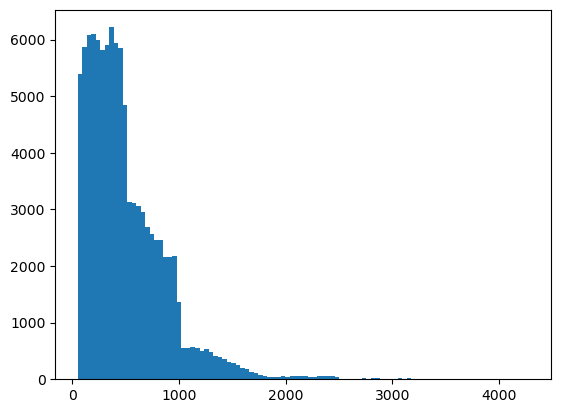

In [ ]:
# La colonne "Booking Value" est la seule à posséder des outliers potentielles (le
# max est très au-dessus du troisième quartile), donc on vérifie l'histogramme de
# cette grandeur pour s'assurer que ces valeurs semblent cohérentes avec la
# distribution générale.
import matplotlib.pyplot as plt
plt.hist(df["Booking Value"], bins=100)

### 6. Sauvegarde des données propres

Enregistrez vos données de base nettoyées dans le répertoire `data/processed/`.

In [ ]:
processed_path = '../data/processed/cleaned_data_sample.csv'
# TODO: Sauvegarder avec df.to_csv()
df_final.to_csv(processed_path, index=False)
print(f"💾 Données propres sauvegardées dans : {processed_path}")